Aşağıda verdiğin isteğe uygun şekilde Python Mesa kütüphanesi kullanılarak zamanla ajan sayısı değişen (ajanlar piyasaya girip çıkıyor) basit bir finansal piyasa modeli

 Özellikler

Her ajan alım/satım yaparak piyasayı etkiler.

Ajanlar her adımda belirli bir olasılıkla sisteme katılır veya sistemden çıkar.

Piyasa fiyatı, ajanların toplam alım/satım kararlarına göre güncellenir.

Ajan sayısı zamanla değişir.

In [2]:
!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random

In [4]:
#  MarketAgent Sınıfı



class MarketAgent(mesa.Agent):
    def __init__(self,model, sermaye):
        super().__init__(model)
        self.sermaye = sermaye

    def step(self):
        # %5'lik bir işlem yapar (rastgele alım veya satım)
        self.islem = random.uniform(-1, 1) * self.sermaye * 0.05
        self.model.toplam_islem += self.islem


In [9]:
#MarketModel Sınıfı

from mesa.datacollection import DataCollector

class MarketModel(mesa.Model):
    def __init__(self, baslangic_ajan_sayisi=50, giris_olasiligi=0.1, cikis_olasiligi=0.05, baslangic_fiyat=100):
        super().__init__()

        self.next_id = 0
        self.fiyat = baslangic_fiyat
        self.toplam_islem = 0
        self.giris_olasiligi = giris_olasiligi
        self.cikis_olasiligi = cikis_olasiligi

        # Başlangıç ajanları
        for _ in range(baslangic_ajan_sayisi):
            self.yeni_ajan_ekle()

        # Veri toplayıcı
        self.datacollector = DataCollector(
            model_reporters={"Fiyat": lambda m: m.fiyat, "AjanSayisi": lambda m: len(m.agents)}
        )

    def yeni_ajan_ekle(self):
        sermaye = random.uniform(100, 1000)
        ajan = MarketAgent(self, sermaye)
        self.agents.add(ajan)


    def step(self):
        self.toplam_islem = 0

        # Ajan adımları
        self.agents.do("step")

        # Fiyat güncelle
        ajan_sayisi = max(len(self.agents), 1)
        self.fiyat += self.toplam_islem / ajan_sayisi

        # Yeni ajan ekle
        if random.random() < self.giris_olasiligi:
            self.yeni_ajan_ekle()

        # Ajan çıkart
        cikacak_ajanlar = [a for a in self.agents if random.random() < self.cikis_olasiligi]
        for ajan in cikacak_ajanlar:
            self.agents.remove(ajan)

        self.datacollector.collect(self)


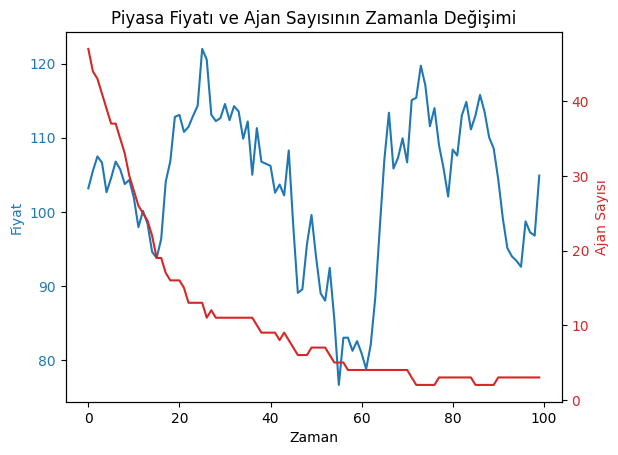

In [10]:
# Simülasyonu Çalıştırmak ve Sonuçları Görselleştirmek

import matplotlib.pyplot as plt

# Modeli çalıştır
model = MarketModel()
for _ in range(100):
    model.step()

# Veriyi al
data = model.datacollector.get_model_vars_dataframe()

# Görselleştir
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel("Zaman")
ax1.set_ylabel("Fiyat", color=color)
ax1.plot(data["Fiyat"], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("Ajan Sayısı", color=color)
ax2.plot(data["AjanSayisi"], color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Piyasa Fiyatı ve Ajan Sayısının Zamanla Değişimi")
plt.show()


Bu kod, ajan sayısı dinamik olarak değişen ve fiyatın ajanların kararlarına göre dalgalandığı basit bir Mesa tabanlı finansal model oluşturur.

Devamında şunlar da eklenebilir:

Ajan türleri (momentum, fundamental vs)

Risk profilleri

Ajan davranışlarının evrimi

İlerletmek ister misin? Örneğin, öğrenen ajanlar, farklı stratejiler veya haber etkisi gibi?